In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/retail_black_friday_sales_100k.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   customer_id       100000 non-null  object 
 2   age_group         100000 non-null  object 
 3   gender            100000 non-null  object 
 4   city              100000 non-null  object 
 5   customer_segment  100000 non-null  object 
 6   product_id        100000 non-null  object 
 7   product_category  100000 non-null  object 
 8   original_price    100000 non-null  float64
 9   discount_pct      100000 non-null  int64  
 10  final_price       100000 non-null  float64
 11  quantity          100000 non-null  int64  
 12  purchase_amount   100000 non-null  float64
 13  payment_method    100000 non-null  object 
 14  purchase_date     100000 non-null  object 
 15  purchase_hour     100000 non-null  int64  
 16  is_weekend        100

###Questions To Be Explored
Which product categories perform best during Black Friday?
Do higher discounts always lead to higher sales?
Which customer segments spend the most?
What time of day drives the most purchases?
How does purchase behavior vary across cities?

*   Which product categories perform best during Black Friday?
*   Do higher discounts always lead to higher sales?


*   Which customer segments spend the most?
*   What time of the day drives the most purchases?

*   How does purchase behaviour vary across various cities







In [5]:
df.head()

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35,99.92,1,99.92,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40,138.03,1,138.03,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25,131.00,1,131.00,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40,239.77,1,239.77,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30,84.61,2,169.22,Debit Card,2025-11-25,2,0,0


In [4]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [transaction_id, customer_id, age_group, gender, city, customer_segment, product_id, product_category, original_price, discount_pct, final_price, quantity, purchase_amount, payment_method, purchase_date, purchase_hour, is_weekend, is_black_friday]
Index: []


In [6]:
df = df.drop(columns=['transaction_id', 'customer_id','product_id','payment_method'])

####Which Product Categories Perform The Best During Black Friday?

product_category
Accessories       1348
Footwear          1284
Books             1278
Clothing          1276
Groceries         1272
Sports            1261
Beauty            1242
Electronics       1231
Toys              1223
Home & Kitchen    1218
Name: is_black_friday, dtype: int64


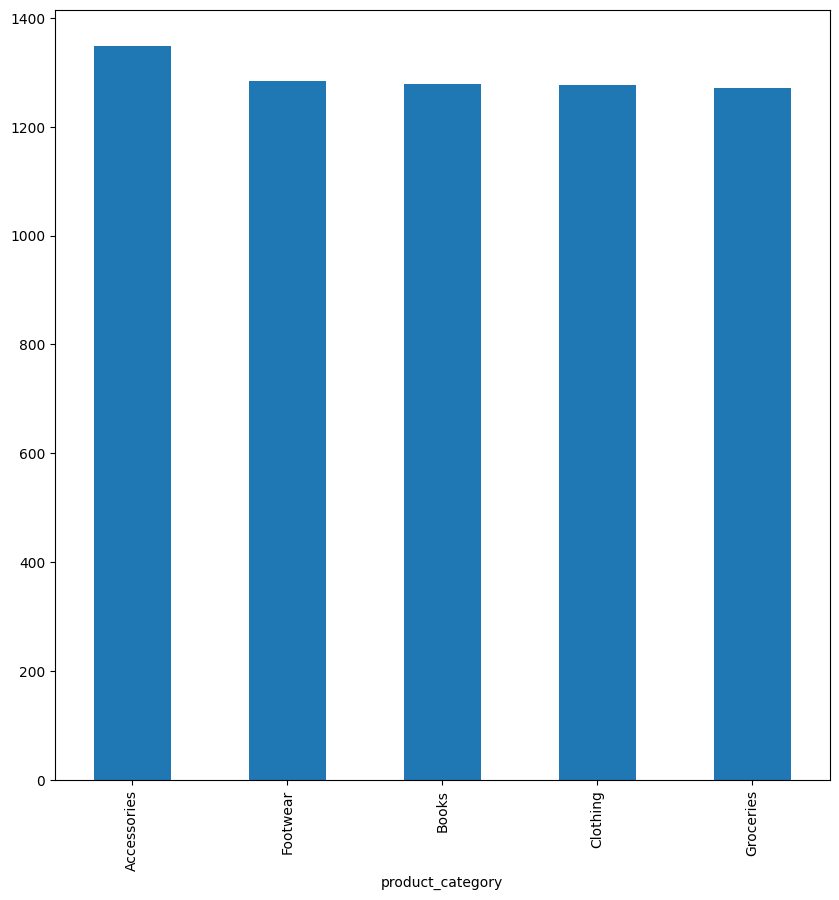

In [19]:
top_categories_during_black_friday = df[df['is_black_friday']==1].groupby('product_category')['is_black_friday'].count().sort_values(ascending = False)
print(top_categories_during_black_friday)
top_5_categories = top_categories_during_black_friday.head(5)
top_5_categories.plot(kind = 'bar',figsize =(10,10))
plt.show()

####Do Higher Discounts Always Lead To Higher Sales?

Correlation between Discount and Cart Size: -0.10


<Axes: >

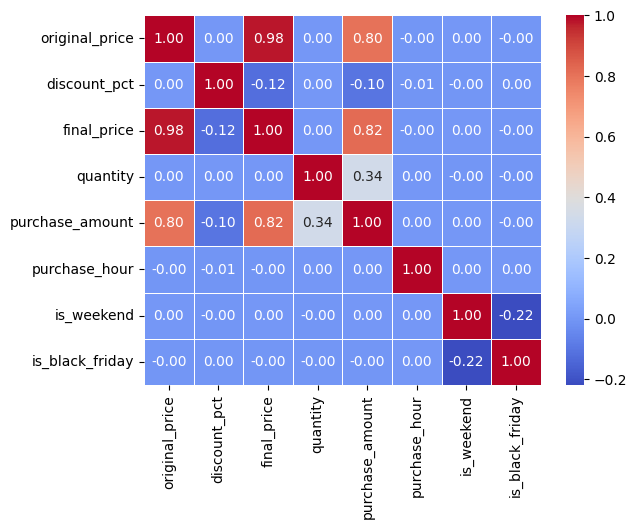

In [31]:
discount_sales_corr = df['discount_pct'].corr(df['purchase_amount'])
print(f"Correlation between Discount and Cart Size: {discount_sales_corr:.2f}")
sns.heatmap(df.corr(numeric_only = True),annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

####Which Customer Segments Spend The Most?

customer_segment
Returning    12125507.74
New          10574443.42
Loyal         8888416.70
VIP           3537262.81
Name: purchase_amount, dtype: float64


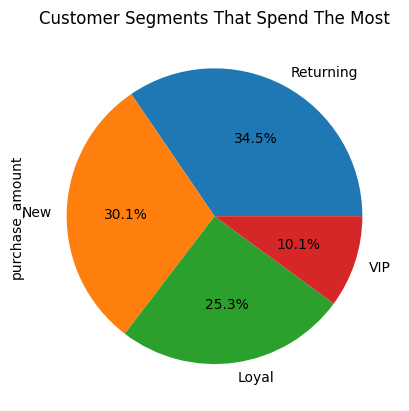

In [39]:
top_customer_segments = df.groupby('customer_segment')['purchase_amount'].sum().sort_values(ascending = False)
print(top_customer_segments)
top_customer_segments.plot(kind = 'pie',autopct='%1.1f%%')
plt.title('Customer Segments That Spend The Most')
plt.show()

####What Time Of The Day Drives The Most Purchases?

In [41]:
best_time_of_day = df['purchase_hour'].value_counts().sort_values(ascending = False).head(5)
print(best_time_of_day)

purchase_hour
10    4295
17    4291
22    4261
15    4246
6     4238
Name: count, dtype: int64


####How Does Purchase Behaviour Vary Across Cities?

In [52]:
city_counts = df['city'].value_counts()
top_cities = city_counts.sort_values(ascending = True)
top_cities_mean = city_counts.mean()
top_cities_std_dev = city_counts.std()
print(top_cities)
print(top_cities_mean)
print(top_cities_std_dev)

city
Los Angeles       9719
Chicago           9954
San Francisco     9968
Dallas            9990
Houston          10024
Phoenix          10032
Miami            10036
Atlanta          10075
Seattle          10097
New York         10105
Name: count, dtype: int64
10000.0
111.13355328912446
